# pyolinkanalyze vs R OlinkAnalyze

Side-by-side comparison of the Python port against the canonical R
implementation on a synthetic NPX dataset.

Requires `OlinkAnalyze` installed in the CMAP R env at
`/scratch/users/steorra/env/CMAP` — see `tests/test_r_parity.py` for
the skip-aware wrapper.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyolinkanalyze as pa
from tests._synth import generate_synthetic_npx

In [2]:
df = generate_synthetic_npx(n_proteins=50, n_samples_per_group=8, seed=0)
df.head()

,SampleID,OlinkID,UniProt,Assay,Panel,NPX,QC_Warning,LOD,Treatment
0,S000,OID00000,P00000,prot_0000,Inflammation,0.178242,PASS,-3.904862,group0
1,S001,OID00000,P00000,prot_0000,Inflammation,0.977610,PASS,-3.042156,group0
2,S002,OID00000,P00000,prot_0000,Inflammation,0.307578,PASS,-2.892044,group0
3,S003,OID00000,P00000,prot_0000,Inflammation,-0.091810,PASS,-4.619549,group0
4,S004,OID00000,P00000,prot_0000,Inflammation,-0.747096,PASS,-4.821608,group0


In [3]:
res = pa.olink_ttest(df, variable='Treatment')
res.head(10)

,OlinkID,Assay,UniProt,Panel,term,estimate,statistic,p.value,Adjusted_pval,Threshold
0,OID00011,prot_0011,P00011,Inflammation,group1 - group0,-1.555431,-13.274125,2.556242e-08,0.000001,1
1,OID00046,prot_0046,P00046,Inflammation,group1 - group0,-1.727220,-9.799180,3.206794e-07,0.000006,1
2,OID00038,prot_0038,P00038,Inflammation,group1 - group0,1.683522,9.395350,3.867921e-07,0.000006,1
3,OID00008,prot_0008,P00008,Inflammation,group1 - group0,-1.681546,-8.333469,6.523083e-06,0.000082,1
4,OID00022,prot_0022,P00022,Inflammation,group1 - group0,1.294715,6.833790,1.715583e-05,0.000172,1
5,OID00013,prot_0013,P00013,Inflammation,group1 - group0,-1.595833,-6.275350,2.220418e-05,0.000185,1
6,OID00029,prot_0029,P00029,Inflammation,group1 - group0,0.688807,3.204792,6.359846e-03,0.045427,1
7,OID00021,prot_0021,P00021,Inflammation,group1 - group0,-0.701888,-2.807602,1.638909e-02,0.102432,0
8,OID00002,prot_0002,P00002,Inflammation,group1 - group0,-0.966904,-2.019353,6.700231e-02,0.372235,0
9,OID00031,prot_0031,P00031,Inflammation,group1 - group0,-0.386732,-1.873778,9.053040e-02,0.452652,0


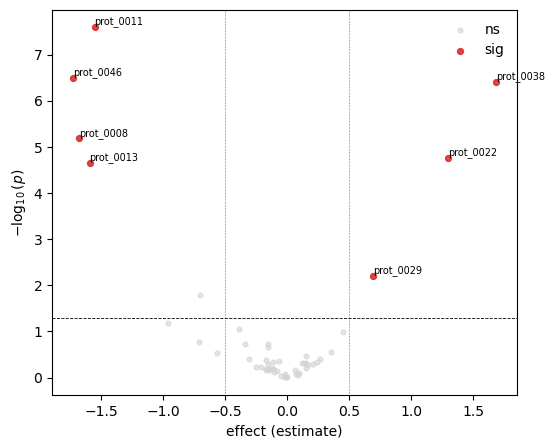

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
pa.olink_volcano_plot(res, ax=ax)
plt.show()

## Compare against R

Dump the same synthetic NPX to TSV, run the R driver, then check
Pearson r on the p-values.

In [5]:
import subprocess, json, tempfile
WORK = Path(tempfile.mkdtemp(prefix='olink_cmp_'))
df.to_csv(WORK / 'npx.tsv', sep='\t', index=False, na_rep='NA')
cmd = (
    'source /home/users/steorra/miniforge3/etc/profile.d/conda.sh '
    '&& conda activate /scratch/users/steorra/env/CMAP '
    f"&& Rscript {Path('..').resolve() / 'tests' / 'r_reference_driver.R'} "
    f"{WORK / 'npx.tsv'} {WORK / 'R_out'}"
)
r = subprocess.run(['bash', '-lc', cmd], capture_output=True, text=True)
print('exit', r.returncode)
print(r.stderr[-400:])

exit 0
Variable converted from character to factor: Treatment
T-test is performed on group0 - group1.
Variable converted from character to factor: Treatment
Mann-Whitney U Test is performed on group0 - group1.



In [6]:
r_tt = pd.read_csv(WORK / 'R_out' / 'ttest.tsv', sep='\t')
if 'OlinkID' in r_tt.columns:
    r_tt = r_tt.set_index('OlinkID')
py_tt = res.set_index('OlinkID')
common = py_tt.index.intersection(r_tt.index)
r_p_col = 'p.value' if 'p.value' in r_tt.columns else 'p_value'
corr_p = np.corrcoef(py_tt.loc[common, 'p.value'], r_tt.loc[common, r_p_col])[0, 1]
print(f'p.value Pearson r between py and R = {corr_p:.4f}')

p.value Pearson r between py and R = 1.0000
